In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print(" Libraries ready!")

✅ Libraries ready!


In [ ]:

df = pd.read_csv('../data/processed/breast_cancer_cleaned.csv')

print(" Data loaded!")
print("Shape:", df.shape)

✅ Data loaded!
Shape: (569, 32)


In [3]:
df.head()

,Unnamed: 0,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [4]:
df.drop(columns=['Unnamed: 0'] , inplace = True)

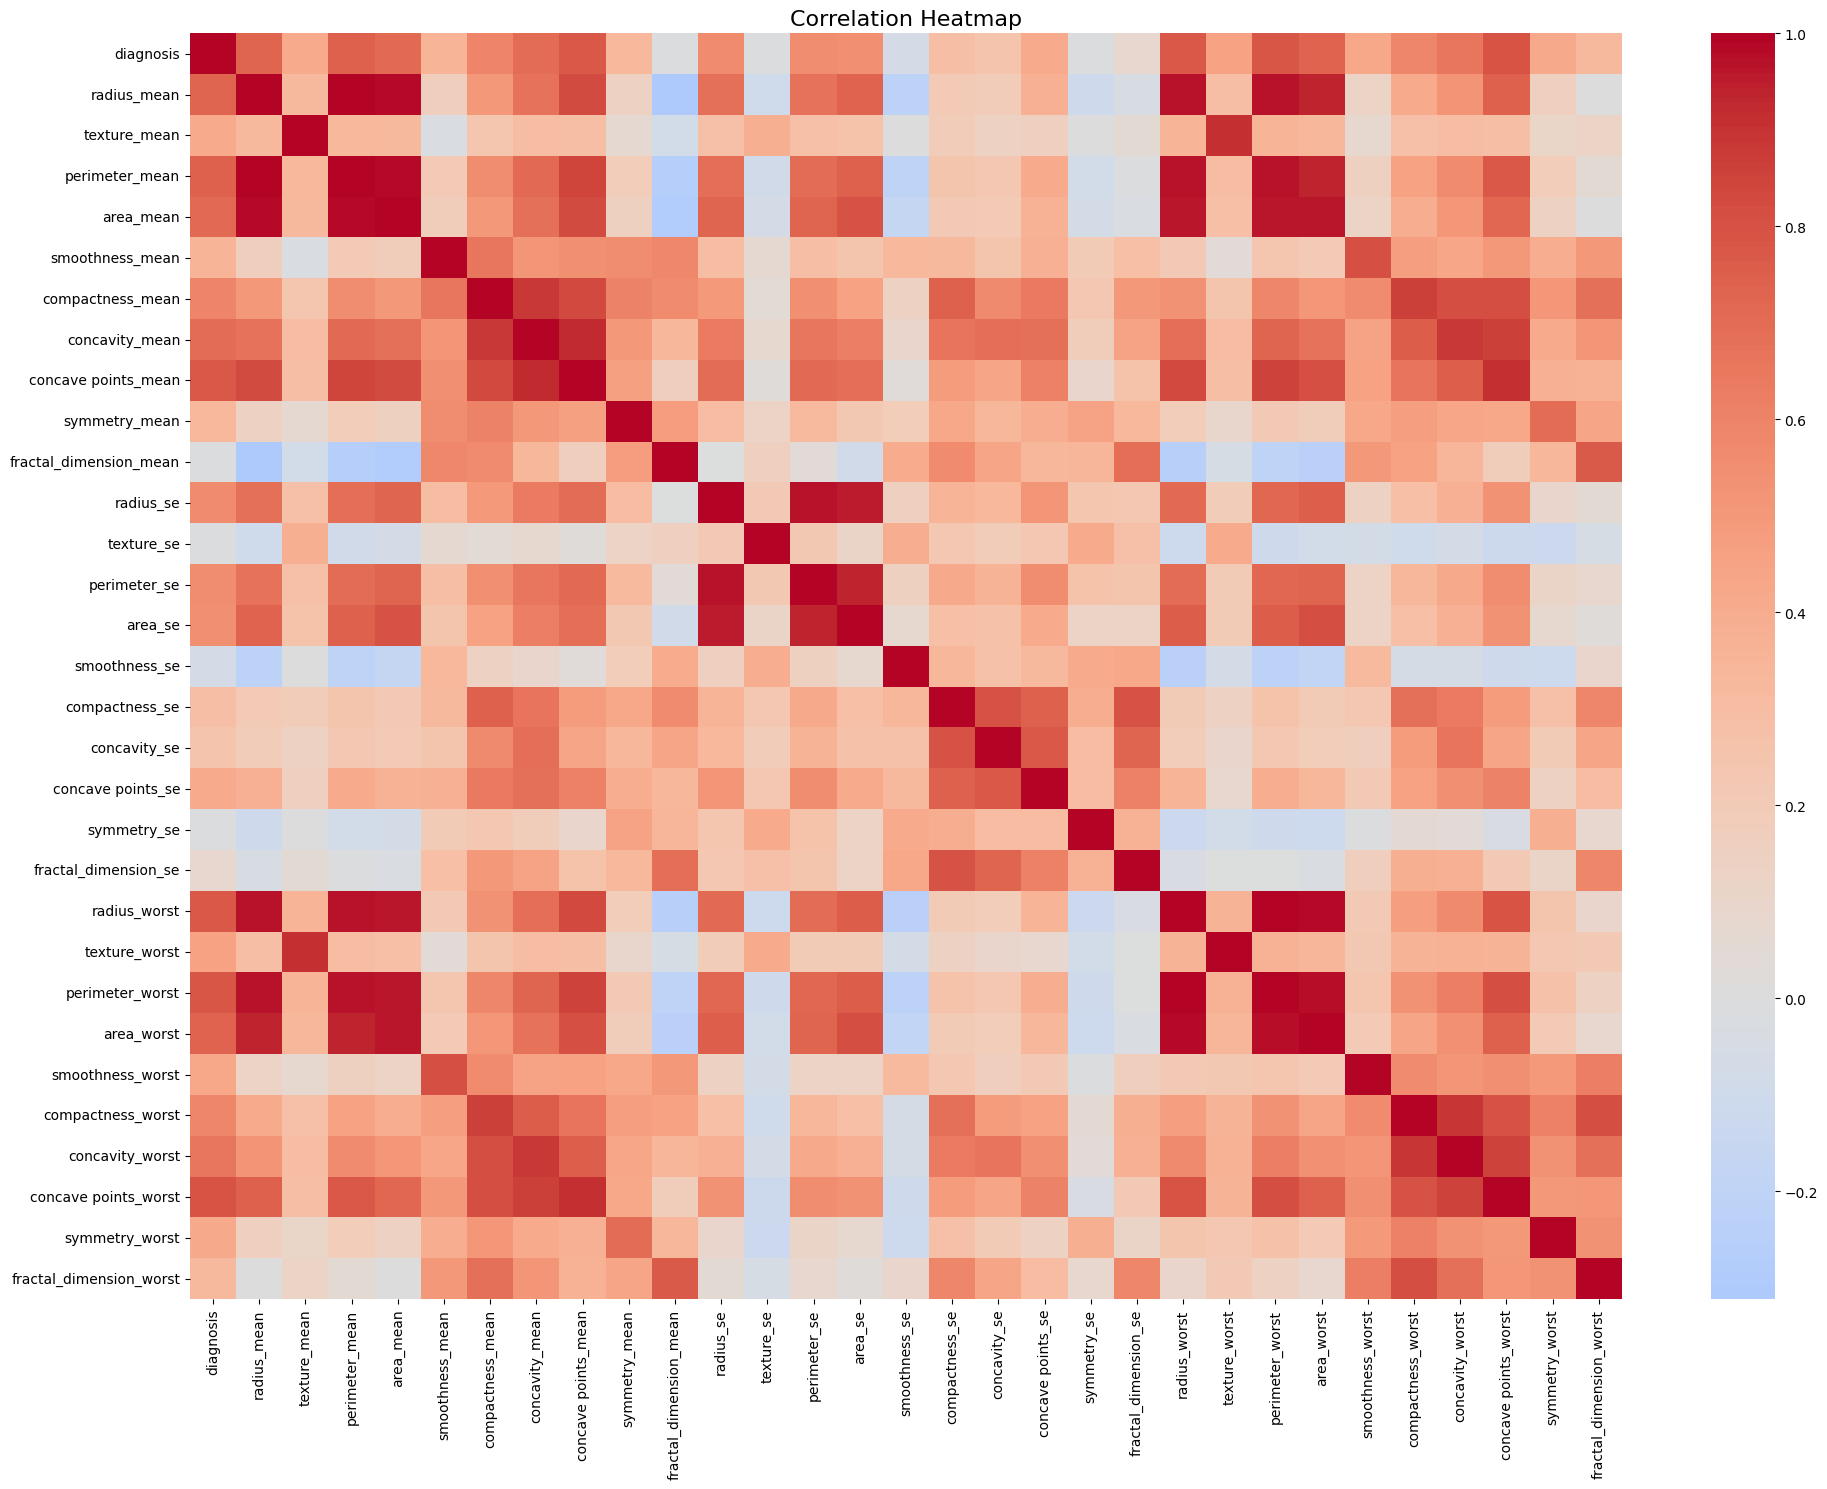

In [5]:
# corelation 
plt.figure(figsize=(20, 15))

sns.heatmap(
    df.corr(),
    annot=False,
    cmap='coolwarm',
    center=0


)

plt.title('Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png', dpi=150)
plt.show()

In [6]:
# top coreleted fitures 

correlation_with_diagnosis = df.corr()['diagnosis'].abs().sort_values(ascending=False)
print(correlation_with_diagnosis.head(10))

diagnosis               1.000000
concave points_worst    0.793566
perimeter_worst         0.782914
concave points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
Name: diagnosis, dtype: float64


C:\Users\ABHISHEK KUMAR SINGH\AppData\Local\Temp\ipykernel_12352\3360739559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ABHISHEK KUMAR SINGH\AppData\Local\Temp\ipykernel_12352\3360739559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ABHISHEK KUMAR SINGH\AppData\Local\Temp\ipykernel_12352\3360739559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\ABHISHEK KUMAR SINGH\AppData\Local\Temp\ipykernel_12352\3360739559.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated a

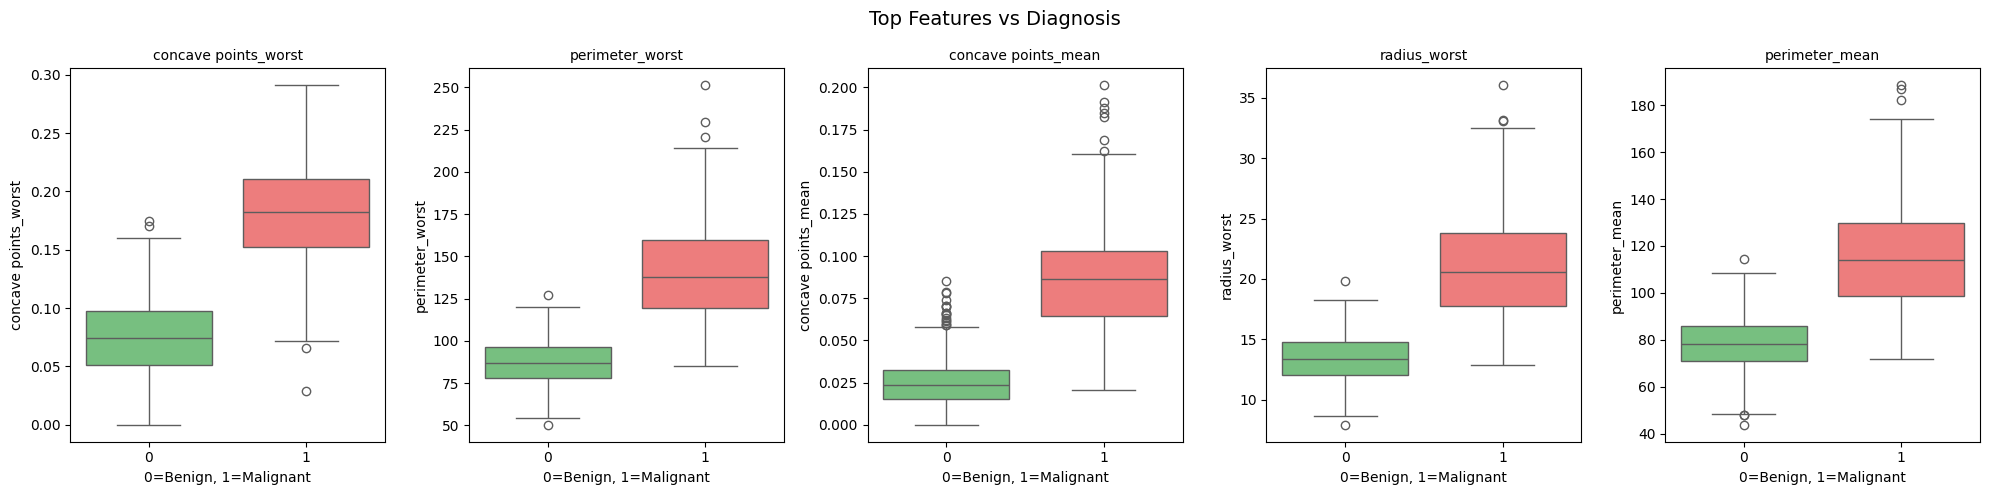

In [7]:
# Top 5 features ka box plot
top_features = ['concave points_worst', 
                'perimeter_worst',
                'concave points_mean',
                'radius_worst',
                'perimeter_mean']

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, feature in enumerate(top_features):
    sns.boxplot(
        x='diagnosis',
        y=feature,
        data=df,
        ax=axes[i],
        palette=['#6BCB77', '#FF6B6B']
    )
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('0=Benign, 1=Malignant')

plt.suptitle('Top Features vs Diagnosis', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/boxplot.png', dpi=150)
plt.show()